In [15]:
%pip install pandas numpy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import pandas as pd
df=pd.read_csv("banguluru.csv")
print(df.head())

   pseudocode  building_status  no_building_blocks  pucca_building_blocks  \
0     9273965                3                   0                      1   
1     4034991                3                   0                      1   
2     9272914                3                   0                      1   
3     4914331                3                   0                      4   
4     4118745                3                   0                      1   

   boundary_wall  total_class_rooms  other_rooms  \
0              1                  0            1   
1              1                  0            4   
2              6                  0            8   
3              1                  0            1   
4              1                  0            1   

   classrooms_in_good_condition  classrooms_needs_minor_repair  \
0                             2                              0   
1                             4                              0   
2                         

In [17]:
print(df.columns)
print(df.info())
print(df.describe())

Index(['pseudocode', 'building_status', 'no_building_blocks',
       'pucca_building_blocks', 'boundary_wall', 'total_class_rooms',
       'other_rooms', 'classrooms_in_good_condition',
       'classrooms_needs_minor_repair', 'classrooms_needs_major_repair',
       'separate_room_for_hm', 'total_boys_toilet', 'total_boys_func_toilet',
       'total_girls_toilet', 'total_girls_func_toilet',
       'total_boys_cwsn_toilet', 'func_boys_cwsn_friendly',
       'total_girls_cwsn_toilet', 'func_girls_cwsn_friendly', 'urinal_boys',
       'urinal_girls', 'handwash_near_toilet', 'hand_pump_yn', 'well_prot_yn',
       'tap_yn', 'othsrc_yn', 'well_unprot_yn', 'pack_water_yn',
       'hand_pump_fun_yn', 'well_prot_fun_yn', 'tap_fun_yn', 'othsrc_fun_yn',
       'well_unprot_fun_yn', 'pack_water_fun_yn', 'rain_water_harvesting',
       'handwash_facility_for_meal', 'electricity_availability', 'solar_panel',
       'library_availability', 'book_bank', 'reading_corner',
       'playground_available', 

In [18]:
df.isnull().sum()

pseudocode               0
building_status          0
no_building_blocks       0
pucca_building_blocks    0
boundary_wall            0
                        ..
projector                0
printer                  0
internet                 0
dth                      0
spl_educator_yn          0
Length: 70, dtype: int64

In [19]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [20]:
df.columns = df.columns.str.strip().str.lower()

In [21]:
features = [
    'electricity_availability',
    'tap_yn',
    'desktop',
    'laptop',
    'tablet',
    'internet'
]

df = df[features]

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

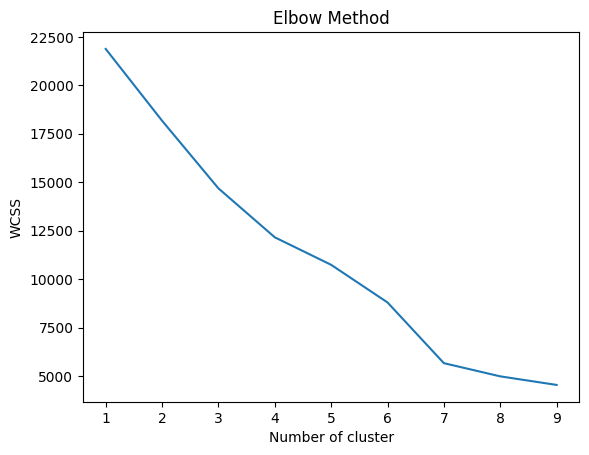

In [23]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss=[]
for i in range(1,10):
    Kmeans = KMeans(n_clusters=i, random_state=42)
    Kmeans.fit(scaled_data)
    wcss.append(Kmeans.inertia_)

plt.plot(range(1,10), wcss)
plt.xlabel("Number of cluster")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [24]:
Kmeans=KMeans(n_clusters=3, random_state=42)
df['Cluster'] = Kmeans.fit_predict(scaled_data)

In [25]:
def label_cluster(x):
    if x==0:
        return "Server Deficit"
    elif x==1:
        return "Moderate Deficit"
    else:
        return "Well Equipped"

df['Deficit_Tier']= df['Cluster'].apply(label_cluster)


In [26]:
print(df.head())

   electricity_availability  tap_yn  desktop  laptop  tablet  internet  \
0                         1       1        0       0       2         2   
1                         1       1        5       0       0         2   
2                         1       2        1       1      85         1   
3                         1       1        0       0       0         1   
4                         1       2        0       0       0         1   

   Cluster      Deficit_Tier  
0        2     Well Equipped  
1        2     Well Equipped  
2        0    Server Deficit  
3        1  Moderate Deficit  
4        0    Server Deficit  


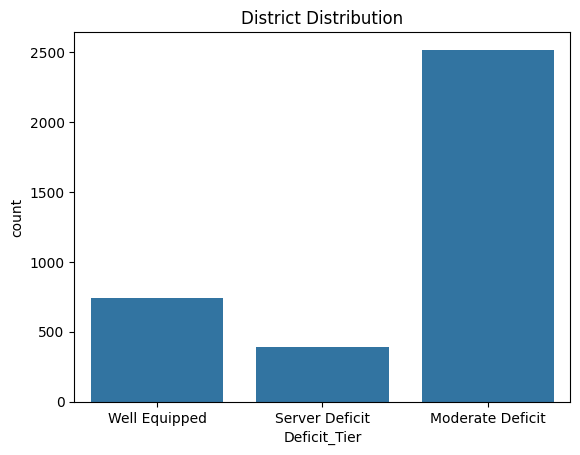

In [27]:
import seaborn as sns

sns.countplot(x='Deficit_Tier', data=df)
plt.title("District Distribution")
plt.show()

In [28]:
df.to_csv("banglore cleaned_data.csv", index=False)